In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from botorch.utils.multi_objective import Hypervolume
from botorch.utils.multi_objective.pareto import is_non_dominated

In [3]:
def get_pareto(Y):
    idx_pareto = is_non_dominated(torch.from_numpy(Y))
    idx_sort = np.argsort(Y[idx_pareto, 0])
    idx_combined = np.where(idx_pareto)[0][idx_sort]

    return Y[idx_combined], idx_combined


def load_data(file_name):
    data = np.load(file_name)
    X = data["train_X"]
    Y = data["train_Y"]
    pareto_Y, idx_pareto = get_pareto(Y)
    Y[:, 1] = -100 * Y[:, 1]
    pareto_Y[:, 1] = -100 * pareto_Y[:, 1]

    return X, Y, pareto_Y, idx_pareto

In [2]:
n_init = 100
colors = ["black", "blue", "orange", "green"]
methods_rename = {
    "RandomBarrierGenerator_3": ("lambda - 3", "black"),
    "RandomBarrierGenerator_4": ("lambda - 4", "blue"),
}
labels = ["All designs", "Initial designs"]
methods = list(methods_rename.keys())
prefixes = ["", "old_"]

In [4]:
for prefix in prefixes:
    X = {}
    Y = {}
    pareto_X = {}
    pareto_Y = {}
    for prefix in prefixes:
        for method in methods:
            key = f"{prefix}{method}"
            file_name = f"results_{method}.npz"
            X[key], Y[key], _, idx = load_data(file_name)
            pareto_X[key] = X[key][idx]
            pareto_Y[key] = Y[key][idx]

In [ ]:
import pandas as pd

data = pd.read_csv("results/metadata.csv")

,method,design,n_barriers,T,ripple
0,RandomBarrierGenerator,0,3,3.729894,15.935383
1,RandomBarrierGenerator,0,4,4.369953,6.752464
2,RandomBarrierGenerator,0,5,3.531796,25.670429
3,RandomBarrierGenerator,1,3,3.379874,17.142984
4,RandomBarrierGenerator,1,4,4.103938,6.980802
...,...,...,...,...,...
281,RandomBarrierGenerator,98,4,4.034400,12.819193
282,RandomBarrierGenerator,98,5,4.299707,12.135849
283,RandomBarrierGenerator,99,3,3.624076,22.225375
284,RandomBarrierGenerator,99,4,4.249243,7.492138


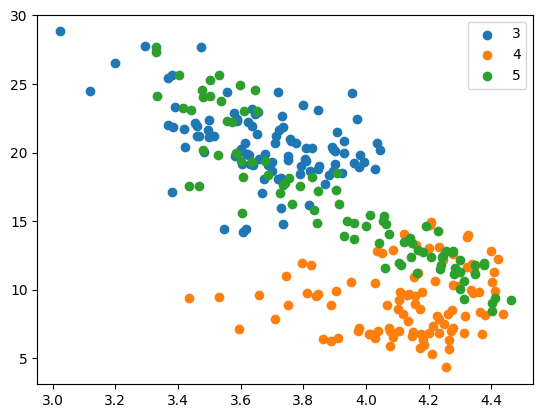

In [19]:

plt.figure()
for i in range(3, 6):
    data_subset = data[data["n_barriers"] == i]
    plt.scatter(data_subset["T"], data_subset["ripple"], label=i)
plt.legend()

In [12]:
y.shape

(100, 2)

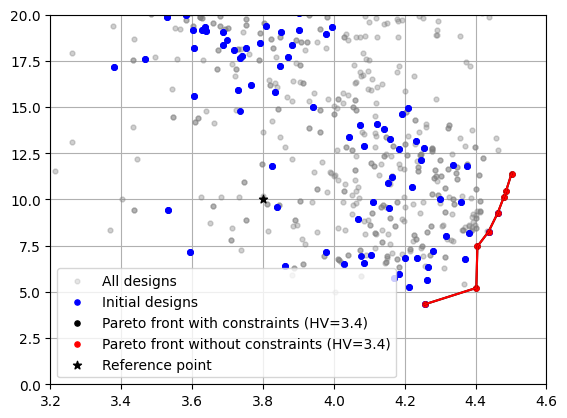

In [19]:
max_ripple = 0.1
ref_point = [3.8, -max_ripple]
hypervolume = Hypervolume(torch.tensor(ref_point))

for i, prefix in enumerate(prefixes):
    Y_all = np.vstack([Y[f"{prefix}{method}"] for method in methods])
    Y_init = np.vstack([Y[f"{prefix}{method}"][:n_init] for method in methods])
    Y_orig = Y_all.copy()
    Y_orig[:, 1] = -1 / 100 * Y_orig[:, 1]
    _, idx = get_pareto(Y_orig)
    Y_pareto = Y_all[idx]
    hv = hypervolume.compute(torch.from_numpy(Y_orig))

    plt.scatter(Y_all[:, 0], Y_all[:, 1], color="gray", alpha=0.2, s=12, zorder=1, label=labels[0] if i == 0 else "")
    plt.scatter(Y_init[:, 0], Y_init[:, 1], color="blue", s=14, label=labels[1] if i == 0 else "")
    if i == 0:
        color = "black"
        label = f"Pareto front with constraints (HV={100 * hv:.1f})"
    else:
        color = "red"
        label = f"Pareto front without constraints (HV={100 * hv:.1f})"
    plt.scatter(Y_pareto[:, 0], Y_pareto[:, 1], color=color, s=14, label=label)
    plt.plot(Y_pareto[:, 0], Y_pareto[:, 1], color=color)
plt.scatter([ref_point[0]], [-100 * ref_point[1]], color="black", label="Reference point", marker="*")

plt.xlim([3.2, 4.6])
plt.ylim([0, 20])
plt.legend()
plt.grid()
ax = plt.gca()
ax.set_axisbelow(True)
plt.savefig("all_designs.png", dpi=600, bbox_inches="tight")

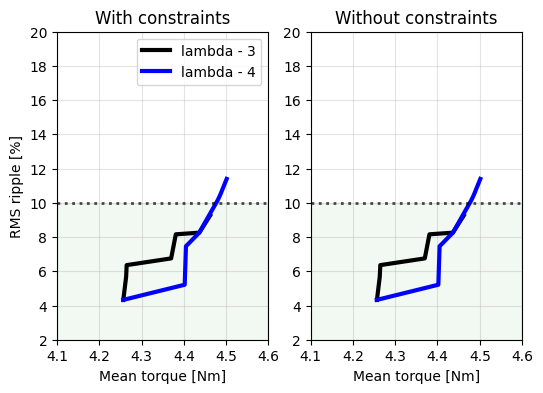

In [17]:
plt.figure(figsize=(6, 4))
for i, prefix in enumerate(prefixes):
    ax = plt.subplot(1, 2, i + 1)
    for method in methods:
        Y_pareto = pareto_Y[f"{prefix}{method}"]
        label, color = methods_rename[method]
        plt.plot(Y_pareto[:, 0], Y_pareto[:, 1], label=label, color=color, linewidth=3)
    ax.axhline(10, color="black", linestyle=":", linewidth=2, alpha=0.7)

    if i == 0:
        plt.legend()
        plt.title("With constraints")
        plt.ylabel("RMS ripple [%]")
    else:
        plt.title("Without constraints")

    plt.xlabel("Mean torque [Nm]")
    plt.xlim([4.1, 4.6])
    plt.ylim([2, 20])
    plt.grid(alpha=0.35)
    ax.fill_between([4.1, 4.6], 0, 10, color="green", alpha=0.05)
plt.savefig("result.png", dpi=600, bbox_inches="tight")